## Data Analysis

This chapter provides a comprehensive exploratory data analysis of the vehicle registration dataset. The analysis examines the temporal structure, statistical properties, and relationships within the data to inform the subsequent modeling approach.

The analysis is structured into several key sections: descriptive statistics and distribution patterns across vehicle types and manufacturers, static correlation analysis to identify relationships between numeric features, time trend visualization to reveal long-term patterns and seasonal effects, autocorrelation analysis to quantify temporal dependencies within individual series, and cross-correlation analysis to assess lagged relationships between exogenous variables and registration volumes.

Understanding these characteristics is essential for designing effective neural network architectures, selecting appropriate input features, and determining suitable sequence lengths for time series forecasting models.

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import ccf
import numpy as np
import math as math

### Data Understanding

For the explorative data analysis the final processed dataset monthly_registration_volume_gold.parquet with all relevant features was used.

In [75]:
storage_path = "../data/gold/monthly_registration_volume_gold.parquet"
df = pd.read_parquet(storage_path, engine='pyarrow')
df.head()

,ts_key,Date,Value,Employment_Level,Employment_Level_Change,Employment_Level_Relative_Change,Employment_Level_YoY_Change,Employment_Level_YoY_Relative_Change,Employment_Level_MA_3,Employment_Level_MA_6,...,Lending_Rate_YoY_Relative_Change,GR_price_with_tax_euro95,GR_price_with_tax_diesel,GR_price_with_tax_heGRing_oil,GR_price_with_tax_fuel_oil_1,OEM,Model,drive_type,Year,Month
0,ALFA ROMEO_GIULIA_All_Wheel_Drive,2018-01-31,54.0,32504413,-104455.0,-0.00320,796982.0,0.02514,3.264763e+07,3.264138e+07,...,0.0,1550.0,1326.0,1018.0,442.14,ALFA ROMEO,GIULIA,All_Wheel_Drive,2018,1
1,ALFA ROMEO_GIULIA_All_Wheel_Drive,2018-02-28,23.0,32550748,46335.0,0.00143,776950.0,0.02445,3.255468e+07,3.266715e+07,...,0.0,1550.0,1325.0,1010.0,424.16,ALFA ROMEO,GIULIA,All_Wheel_Drive,2018,2
2,ALFA ROMEO_GIULIA_All_Wheel_Drive,2018-03-31,85.0,32660492,109744.0,0.00337,730269.0,0.02287,3.257188e+07,3.265527e+07,...,0.0,1533.0,1309.0,991.0,431.53,ALFA ROMEO,GIULIA,All_Wheel_Drive,2018,3
3,ALFA ROMEO_GIULIA_All_Wheel_Drive,2018-04-30,51.0,32782173,121681.0,0.00373,768929.0,0.02402,3.266447e+07,3.265605e+07,...,0.0,1575.0,1348.0,1025.0,453.57,ALFA ROMEO,GIULIA,All_Wheel_Drive,2018,4
4,ALFA ROMEO_GIULIA_All_Wheel_Drive,2018-05-31,77.0,32857311,75138.0,0.00229,725968.0,0.02259,3.276666e+07,3.266067e+07,...,0.0,1647.0,1420.0,1025.0,520.12,ALFA ROMEO,GIULIA,All_Wheel_Drive,2018,5


As already described in the section Data Description the dataset consists of the KBA registration data and exogenous variables.
KBA registration data are describing the registrations of vehicles in Germany including the vehicle model, the timepoint and the number of registrations per month and are shown in the following dataset:



In [76]:
df_kba = df[['ts_key', 'Value', 'Date', 'OEM', 'drive_type', 'Model', 'Month', 'Year']].copy()
df_kba.head()


,ts_key,Value,Date,OEM,drive_type,Model,Month,Year
0,ALFA ROMEO_GIULIA_All_Wheel_Drive,54.0,2018-01-31,ALFA ROMEO,All_Wheel_Drive,GIULIA,1,2018
1,ALFA ROMEO_GIULIA_All_Wheel_Drive,23.0,2018-02-28,ALFA ROMEO,All_Wheel_Drive,GIULIA,2,2018
2,ALFA ROMEO_GIULIA_All_Wheel_Drive,85.0,2018-03-31,ALFA ROMEO,All_Wheel_Drive,GIULIA,3,2018
3,ALFA ROMEO_GIULIA_All_Wheel_Drive,51.0,2018-04-30,ALFA ROMEO,All_Wheel_Drive,GIULIA,4,2018
4,ALFA ROMEO_GIULIA_All_Wheel_Drive,77.0,2018-05-31,ALFA ROMEO,All_Wheel_Drive,GIULIA,5,2018


Idd addition to the KBA registration data exogenous data, which are mainly economic data were included into the dataset. These variables are listed in the following:

In [77]:
df_exogenous = df.drop(columns=['ts_key', 'Value', 'Date', 'OEM', 'drive_type', 'Model', 'Month', 'Year']).copy()
df_exogenous.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107917 entries, 0 to 107916
Data columns (total 24 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Employment_Level                      107917 non-null  int64  
 1   Employment_Level_Change               107917 non-null  float64
 2   Employment_Level_Relative_Change      107917 non-null  float64
 3   Employment_Level_YoY_Change           107917 non-null  float64
 4   Employment_Level_YoY_Relative_Change  107917 non-null  float64
 5   Employment_Level_MA_3                 107917 non-null  float64
 6   Employment_Level_MA_6                 107917 non-null  float64
 7   consumer_price_index                  107917 non-null  float64
 8   YoY_change                            107917 non-null  float64
 9   MoM_change                            107917 non-null  float64
 10  Deposit_Rate                          107917 non-null  float64
 11  

In [78]:
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns in the dataset.")
print(f"There are {df['ts_key'].nunique()} unique time series in the dataset.")

There are 107917 rows and 32 columns in the dataset.
There are 1502 unique time series in the dataset.


In [79]:
#show summary statistics of Value column
df['Value'].describe()

count    107917.000000
mean        432.691847
std         874.739536
min           0.000000
25%           4.000000
50%          88.000000
75%         459.000000
max       22335.000000
Name: Value, dtype: float64

### Univariate Analysis

In the following section, the distribution of vehicle registrations across different categorical variables is examined. This analysis focuses on understanding how registration volumes are distributed among various vehicle types (drive types) and manufacturers (OEMs). By aggregating total registrations for each category, we can identify which segments dominate the market and reveal potential imbalances in the dataset that may influence model performance. These insights help determine whether certain categories require special attention during modeling, such as stratified sampling or category-specific models.

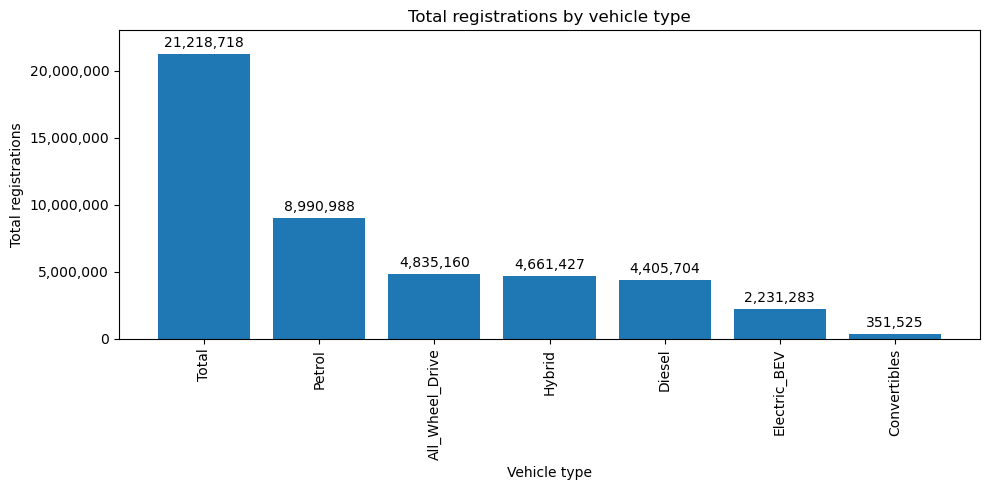

In [80]:
sum_by_type = (df.groupby("drive_type")["Value"].sum().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(sum_by_type.index, sum_by_type.values)

ax.set(
    title="Total registrations by vehicle type",
    xlabel="Vehicle type",
    ylabel="Total registrations",
    ylim=(0, 23000000)
)

ax.tick_params(axis="x", rotation=90)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)


ax.bar_label(
    bars,
    labels=[f"{int(v):,}" for v in sum_by_type.values],
    padding=3
)

plt.tight_layout()
plt.show()


The distribution of vehicle registrations across drive types reveals substantial class imbalance in the dataset. Petrol vehicles dominate with approximately 8.99 million registrations across the observation period, while convertibles represent the smallest segment with only 352,000 registrations—a difference of more than 25-fold. This significant imbalance has important implications for model training, as neural networks may exhibit bias toward predicting well-represented classes. 

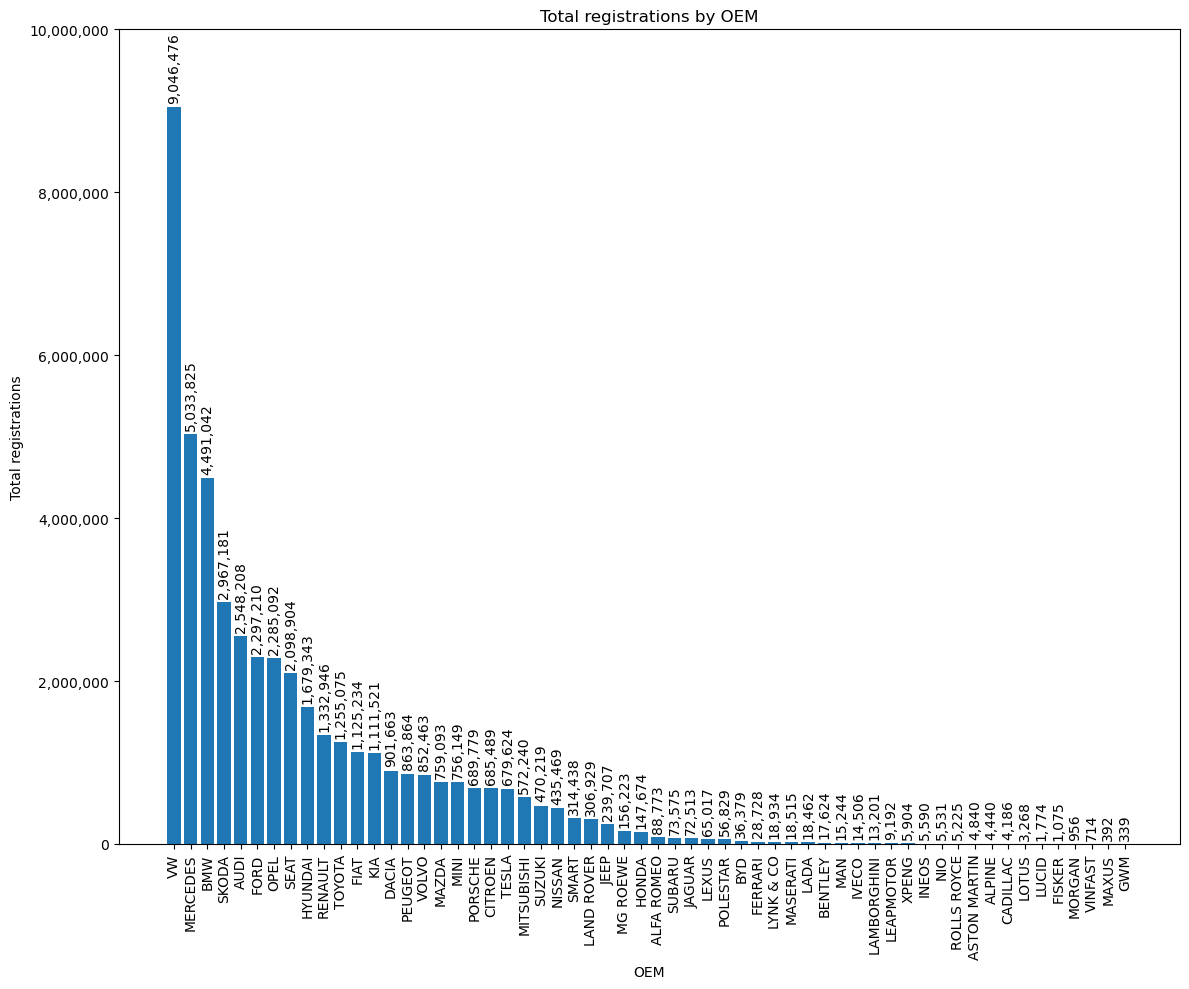

In [81]:
sum_by_oem = (df.groupby("OEM")["Value"].sum().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.bar(sum_by_oem.index, sum_by_oem.values)

ax.set(
    title="Total registrations by OEM",
    xlabel="OEM",
    ylabel="Total registrations",
    ylim=(0, 10_000_000)
)

ax.tick_params(axis="x", rotation=90)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)

ax.bar_label(
    bars,
    labels=[f"{int(v):,}" for v in sum_by_oem.values],
    rotation=90,
    padding=3
)

plt.tight_layout()
plt.show()

A similar imbalance exists in the distribution of registrations across manufacturers (OEMs). Volkswagen (VW) dominates the market with approximately 9.0 million total registrations throughout the observation period, while GWM represents the opposite extreme with only 339 registered vehicles. The bar chart reveals that several OEMs have fewer than 10,000 total registrations, highlighting extreme variability in manufacturer representation. 

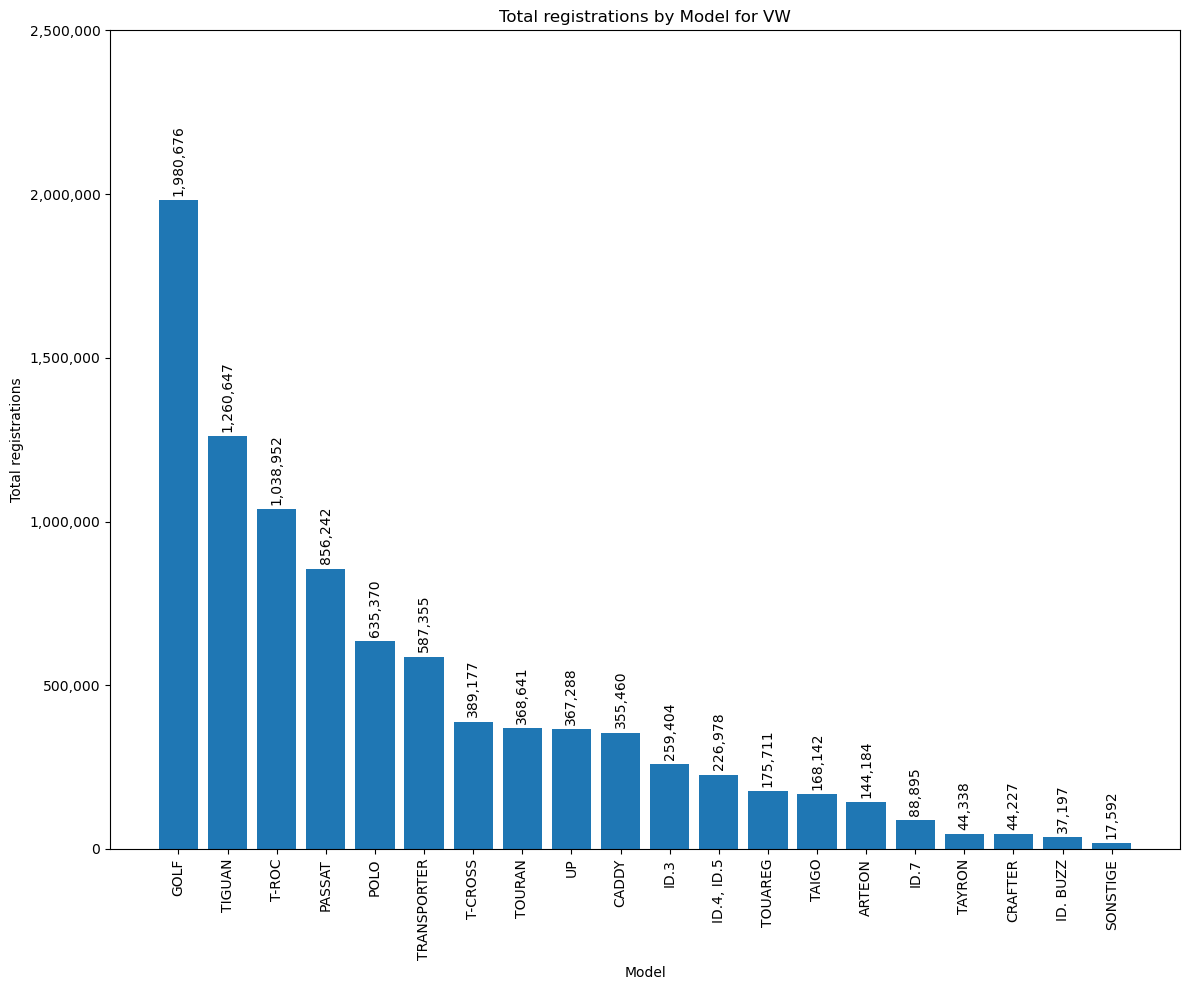

In [82]:
sum_by_model = (df[df["OEM"] == "VW"].groupby("Model")["Value"].sum().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.bar(sum_by_model.index, sum_by_model.values)

ax.set(
    title="Total registrations by Model for VW",
    xlabel="Model",
    ylabel="Total registrations",
    ylim=(0, 2_500_000)
)

ax.tick_params(axis="x", rotation=90)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)

ax.bar_label(
    bars,
    labels=[f"{int(v):,}" for v in sum_by_model.values],
    rotation=90,
    padding=3
)

plt.tight_layout()
plt.show()


To understand the distribution of registration volumes across individual vehicle models within a manufacturer, the chart above displays all VW models and their respective registration totals. Substantial variation exists between different models within the VW portfolio, mirroring the imbalance observed at the OEM level. 
Low-volume models present particular challenges for forecasting, as insufficient sample sizes lead to high volatility in monthly registration numbers, making reliable predictions extremely difficult. 

### Contemporaneous correlation

Contemporaneous correlation analysis examines the linear relationships between numeric features in the dataset, regardless of their temporal structure. This analysis is essential for understanding how exogenous variables relate to vehicle registration volumes and to each other, helping to identify potential multicollinearity issues.

The following analysis presents correlation patterns at three levels of granularity: first, an overall correlation matrix across all time series to reveal general relationships; second, correlations segmented by vehicle type to account for differences in how economic factors affect different powertrains; and third, correlations for individual OEMs to capture manufacturer-specific sensitivities to external variables. These insights help determine which exogenous features are most relevant for different segments of the forecasting task.

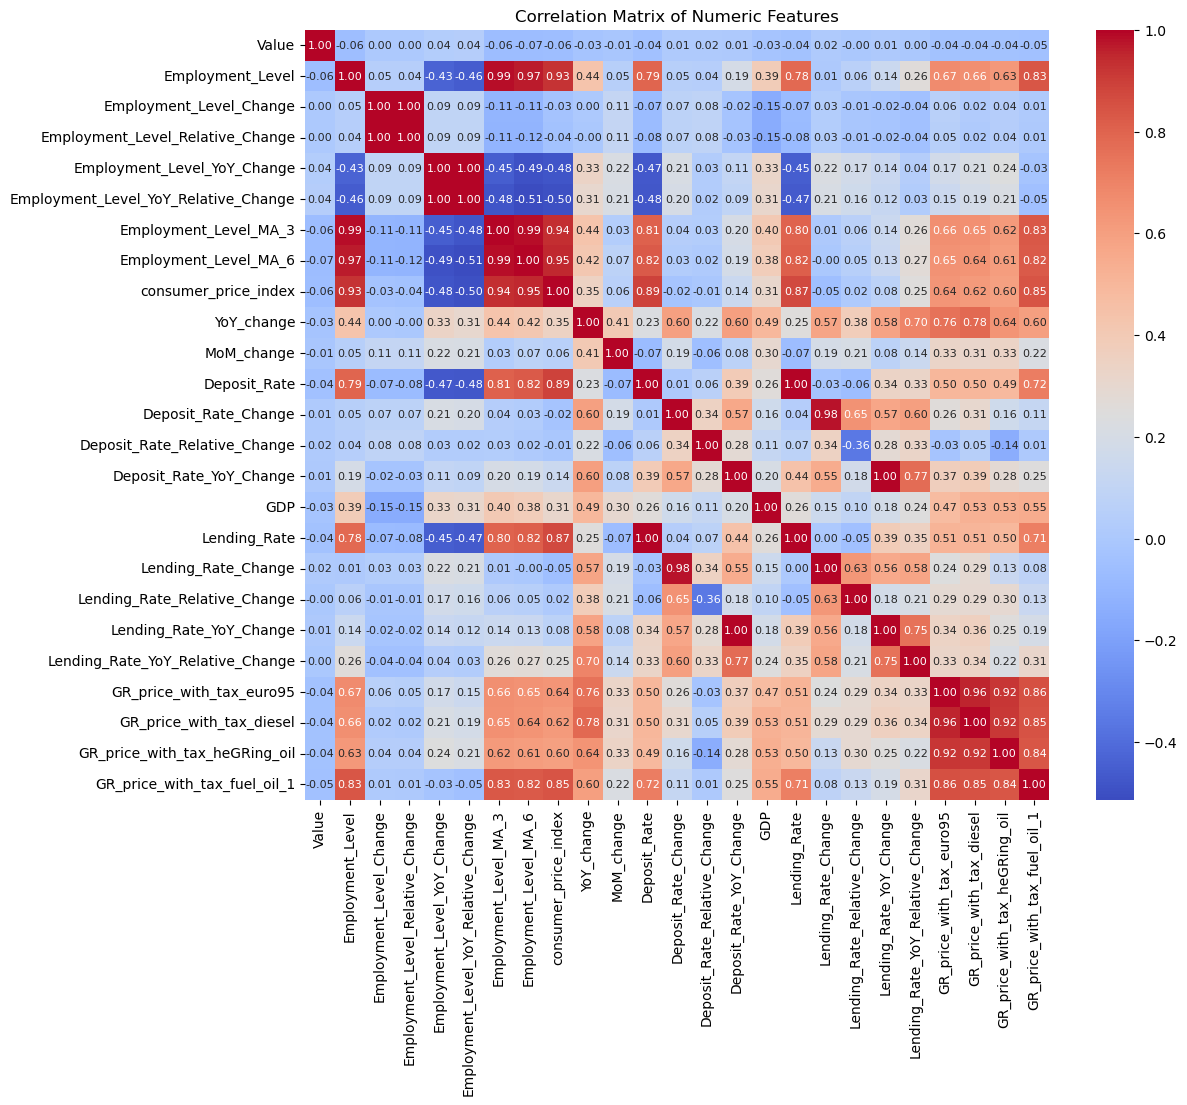

In [83]:
# build dataframe with all numeric columns only and exclude Month and Year
numeric_df = df.select_dtypes(include=['number']).drop(columns=['Month', 'Year'])   

# show correlation matrix of numeric columns
plt.figure(figsize=(12,10))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size": 8})
plt.title("Correlation Matrix of Numeric Features")
plt.show()

The correlation matrix above displays the contemporaneous correlations between all input variables. Examining the correlation of the target variable (Value) across all time series and independent of time reveals almost no correlations with the exogenous features. The highest correlation with input variables is 0.07 for the feature Employment_Level_MA_6.

However, significant multicollinearity is observed between the exogenous variables themselves. For example, the correlation coefficients between all fuel prices (GR_price_with_tax_euro95, GR_price_with_tax_diesel, GR_price_with_tax_heating_oil, GR_price_with_tax_fuel_oil_1) range between 0.84 and 0.96. Economic indicators also show strong interdependencies. For instance, the correlation coefficient between consumer_price_index and Employment_Level_MA_3 is 0.94.

These findings suggest that while individual exogenous variables show weak contemporaneous correlation with registration volumes, they exhibit substantial collinearity among themselves.

In [84]:
types = df['drive_type'].unique().tolist()
num_cols = df.select_dtypes(include="number").columns

corr_list = []
for t in types:
    corr_t = (
        df[df["drive_type"] == t][num_cols]
        .corr()["Value"]
        .drop("Value")
        .rename(t)
    )
    corr_list.append(corr_t)

corr_table = pd.concat(corr_list, axis=1).round(2)

styled = (
    corr_table
    .style
    .background_gradient(
        cmap="RdBu",   # rot = negativ, blau = positiv
        axis=None,
        vmin=-1, vmax=1
    )

)

styled


,All_Wheel_Drive,Diesel,Petrol,Total,Electric_BEV,Hybrid,Convertibles
Employment_Level,-0.050000,-0.170000,-0.170000,-0.110000,0.140000,0.230000,-0.100000
Employment_Level_Change,-0.000000,-0.000000,0.010000,0.000000,-0.010000,-0.010000,0.020000
Employment_Level_Relative_Change,-0.000000,0.000000,0.010000,0.000000,-0.010000,-0.010000,0.020000
Employment_Level_YoY_Change,0.040000,0.080000,0.100000,0.060000,-0.050000,-0.150000,0.040000
Employment_Level_YoY_Relative_Change,0.040000,0.090000,0.100000,0.060000,-0.060000,-0.160000,0.050000
Employment_Level_MA_3,-0.050000,-0.170000,-0.180000,-0.110000,0.140000,0.230000,-0.100000
Employment_Level_MA_6,-0.050000,-0.170000,-0.180000,-0.110000,0.140000,0.230000,-0.090000
consumer_price_index,-0.050000,-0.160000,-0.160000,-0.110000,0.120000,0.220000,-0.070000
YoY_change,-0.010000,-0.090000,-0.090000,-0.050000,0.140000,0.100000,-0.010000
MoM_change,-0.010000,-0.030000,-0.030000,-0.020000,0.010000,0.020000,0.030000


When examining the influence of exogenous features on individual vehicle types (drive_types), correlation coefficients of up to 0.23 emerge for certain categories, in contrast to the negligible correlations observed in the overall analysis. However, the relationships between input variables and different vehicle types vary considerably. While employment level (Employment_Level_MA_3) shows a moderately positive correlation of 0.23 with hybrid vehicle registrations, the relationship between employment level and diesel or petrol vehicle registrations is slightly negative, indicating inverse dynamics across different powertrain segments.

In [85]:
oems_top20 = (df.groupby("OEM")["Value"].sum().sort_values(ascending=False).head(20).index.tolist())
num_cols = df.select_dtypes(include="number").columns

corr_list = []
for t in oems_top20:
    corr_t = (
        df[df["OEM"] == t][num_cols]
        .corr()["Value"]
        .drop("Value")
        .rename(t)
    )
    corr_list.append(corr_t)

corr_table = pd.concat(corr_list, axis=1).round(2)

styled = (corr_table.style.background_gradient(cmap="RdBu", vmin=-1, vmax=1))

styled

,VW,MERCEDES,BMW,SKODA,AUDI,FORD,OPEL,SEAT,HYUNDAI,RENAULT,TOYOTA,FIAT,KIA,DACIA,PEUGEOT,VOLVO,MAZDA,MINI,PORSCHE,CITROEN
Employment_Level,-0.110000,-0.040000,-0.020000,-0.040000,0.070000,-0.190000,-0.040000,-0.060000,-0.230000,-0.180000,-0.040000,-0.120000,0.010000,-0.020000,-0.050000,0.070000,-0.130000,-0.090000,-0.000000,-0.030000
Employment_Level_Change,-0.010000,-0.000000,-0.010000,-0.010000,-0.010000,0.020000,0.020000,0.020000,0.040000,-0.010000,0.020000,0.030000,0.030000,-0.060000,-0.000000,-0.100000,0.050000,0.030000,-0.020000,0.020000
Employment_Level_Relative_Change,-0.010000,-0.000000,-0.010000,-0.000000,-0.010000,0.020000,0.020000,0.020000,0.040000,-0.000000,0.020000,0.030000,0.030000,-0.060000,-0.000000,-0.100000,0.050000,0.030000,-0.020000,0.020000
Employment_Level_YoY_Change,0.050000,0.010000,-0.000000,-0.030000,-0.030000,0.100000,0.030000,-0.010000,0.150000,0.070000,0.020000,0.050000,0.020000,0.040000,0.020000,-0.130000,0.090000,0.050000,0.020000,0.000000
Employment_Level_YoY_Relative_Change,0.050000,0.010000,0.000000,-0.030000,-0.030000,0.110000,0.030000,-0.000000,0.150000,0.080000,0.020000,0.050000,0.020000,0.040000,0.020000,-0.130000,0.100000,0.050000,0.020000,0.010000
Employment_Level_MA_3,-0.110000,-0.040000,-0.020000,-0.040000,0.070000,-0.190000,-0.050000,-0.070000,-0.230000,-0.180000,-0.040000,-0.120000,0.000000,-0.010000,-0.050000,0.080000,-0.140000,-0.100000,0.000000,-0.030000
Employment_Level_MA_6,-0.110000,-0.040000,-0.020000,-0.040000,0.080000,-0.200000,-0.050000,-0.060000,-0.240000,-0.200000,-0.040000,-0.120000,-0.000000,-0.010000,-0.050000,0.080000,-0.150000,-0.100000,0.000000,-0.020000
consumer_price_index,-0.090000,-0.030000,-0.010000,-0.010000,0.090000,-0.180000,-0.050000,-0.030000,-0.250000,-0.200000,-0.030000,-0.130000,-0.010000,0.010000,-0.040000,0.060000,-0.120000,-0.100000,0.020000,0.010000
YoY_change,-0.060000,-0.030000,-0.040000,-0.110000,0.050000,-0.090000,0.000000,-0.100000,-0.060000,-0.080000,-0.030000,-0.000000,0.050000,0.020000,-0.070000,-0.070000,-0.080000,-0.030000,0.010000,-0.050000
MoM_change,-0.030000,-0.030000,-0.040000,-0.050000,-0.010000,-0.040000,-0.010000,-0.050000,-0.020000,-0.050000,-0.010000,0.020000,-0.010000,-0.030000,-0.040000,-0.060000,-0.020000,-0.030000,0.030000,-0.000000


The correlation matrix above displays the influence of individual exogenous features on registration volumes for the top 20 manufacturers (OEMs) by total registrations. In contrast to the aggregated analysis, moderate correlations between input variables and individual OEMs emerge at this granular level. However, correlation strengths vary substantially across manufacturers. For instance, the consumer price index—a proxy for purchasing power—exhibits a moderately negative correlation of -0.25 with Renault registrations, while the same variable shows negligible influence on Mercedes (-0.03) and BMW (-0.01) registrations. This heterogeneity suggests that economic sensitivities differ markedly across manufacturer segments.

### Time Trend Analysis

Time trend analysis visualizes the temporal evolution of vehicle registration patterns to identify long-term trends, structural breaks, seasonal patterns, and heterogeneity across different segments. Unlike contemporaneous correlation, this analysis explicitly considers the time dimension to reveal how registration volumes change over the observation period.

This section employs overlay plots to visualize multiple time series simultaneously with high transparency, allowing global patterns to emerge while maintaining visibility of individual series variability. The analysis is conducted at multiple aggregation levels: first, an overall view of all time series to identify dataset-wide trends; second, segmented by vehicle type to reveal powertrain-specific patterns influenced by technological shifts and policy changes; and third, segmented by manufacturer to capture brand-specific market dynamics.

Understanding these temporal patterns is crucial for neural network design, particularly for determining appropriate lookback windows, identifying the need for trend and seasonal components, and recognizing periods of structural change that may require special handling during model training and validation.

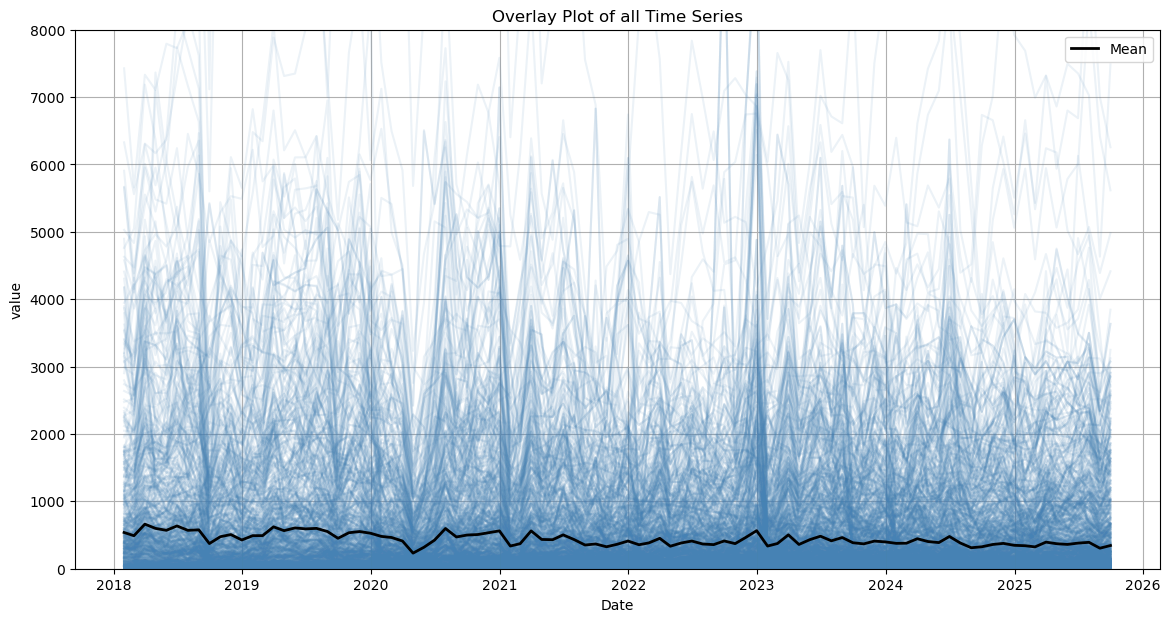

In [86]:
plt.figure(figsize=(14, 7))

for ts_key, g in df.groupby("ts_key"):
    plt.plot(g["Date"], g["Value"], alpha=0.1, color="steelblue")

plt.title("Overlay Plot of all Time Series")
plt.xlabel("Date")
plt.ylabel("value")

mean_series = df.groupby("Date")["Value"].mean()
plt.plot(mean_series.index, mean_series, color="black", linewidth=2, label="Mean")
plt.legend()
plt.ylim(0, 8000)
plt.grid(True)
plt.show()

An overlay plot was used to visualize the temporal structure of all time series in the dataset. Each series was plotted with high transparency to reveal global trends and heterogeneity across the dataset. To provide an impression of the overall trend, the mean number of vehicle registrations across all time series is plotted as a black line.

Examining the transparent blue lines reveals substantial temporal fluctuations in individual vehicle models, with some series reaching over 8,000 registrations per month, while the average registration volume remains relatively stable throughout the observation period. Overall, a slight negative trend in vehicle registrations can be observed over the years.

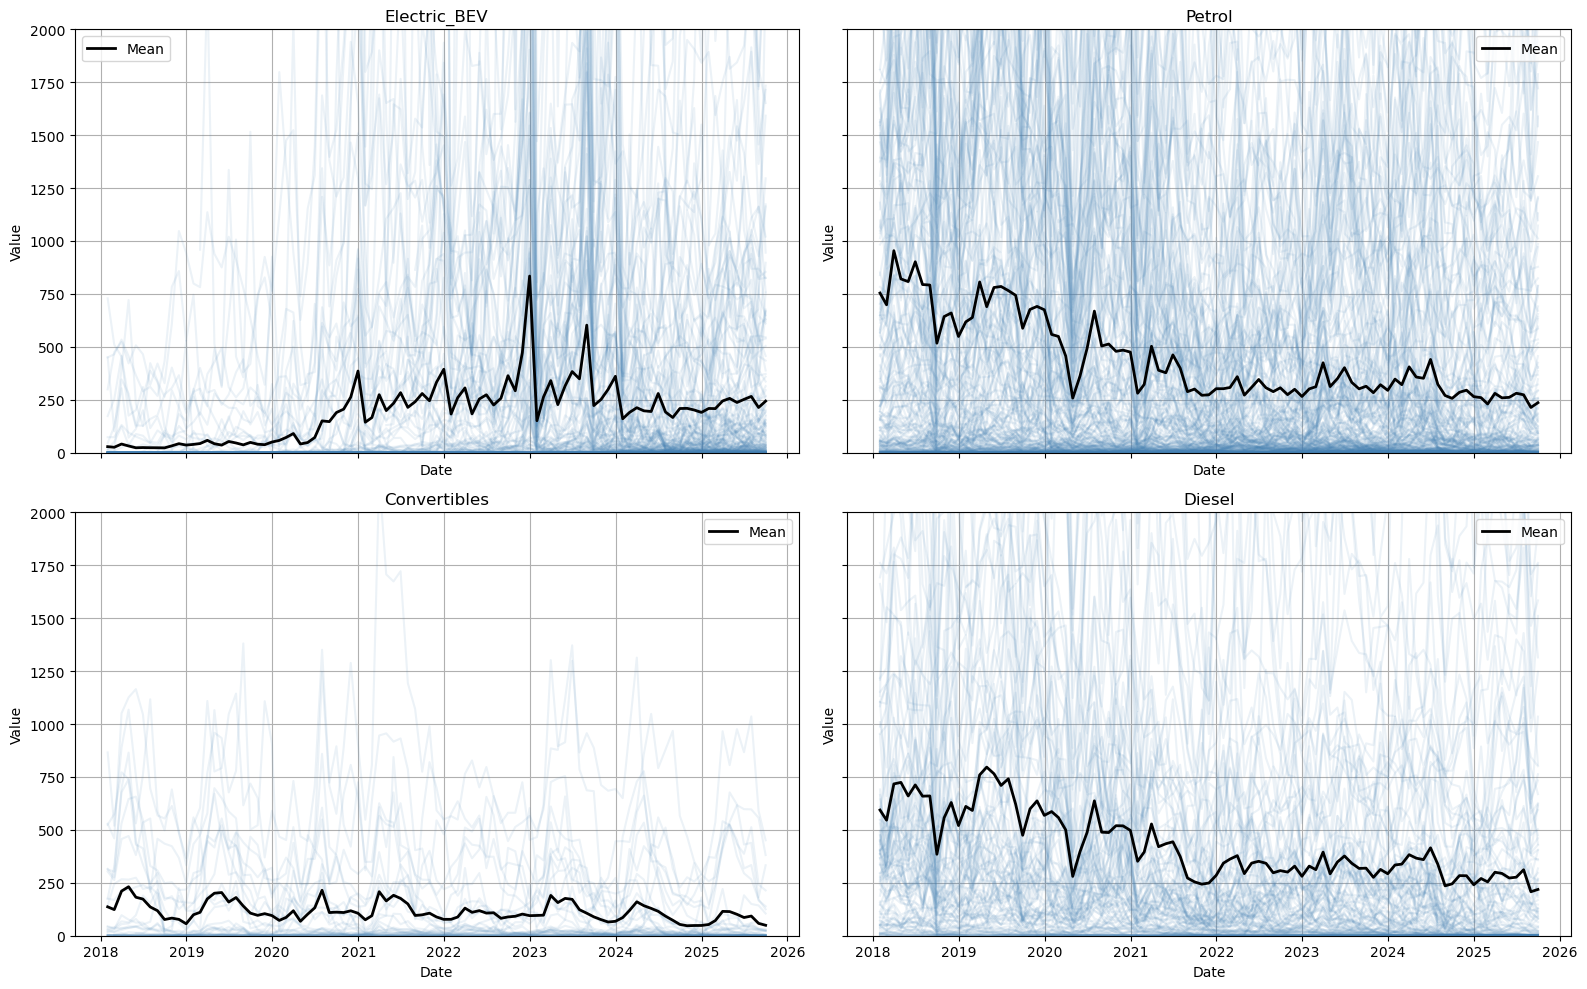

In [87]:
vehicle_types = ["Electric_BEV", "Petrol", "Convertibles", "Diesel"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, v_type in zip(axes, vehicle_types):
    type_df = df[df["drive_type"] == v_type].copy()
    type_df = type_df.sort_values("Date")

    
    for _, g in type_df.groupby("ts_key"):
        ax.plot(g["Date"], g["Value"], alpha=0.1, color="steelblue")

    mean_series = type_df.groupby("Date")["Value"].mean()
    ax.plot(mean_series.index, mean_series, color="black", linewidth=2, label="Mean")

    ax.set_title(f"{v_type}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.set_ylim(0, 2000)
    ax.legend()
    ax.grid(True)
    

plt.tight_layout()
plt.show()

Battery electric vehicles (BEVs) exhibit the most irregular temporal patterns among all drive types, characterized by substantial fluctuations. Registration volumes remained very low until 2020, followed by a sharp increase in the subsequent year. Extreme spikes throughout the observation period can only be explained by external one-time factors such as policy interventions and government subsidies. This high volatility significantly complicates forecasting of electric vehicle registrations.

Petrol and diesel vehicles show relatively lower noise compared to their total registration volumes. A clear negative trend in average registration numbers per model is evident throughout the observation period.

Convertibles, in contrast to other vehicle types, display strong seasonality. Average registration numbers rise and fall within each year following a regular pattern, while also exhibiting a negative trend from 2018 to 2025.

Examining individual model trajectories (blue transparent lines) across all diagrams reveals an absence of clear trends at the individual series level. This indicates that registration volumes within individual time series contain excessive noise, making reliable forecasting of individual models challenging without incorporating higher-level aggregated features or cross-sectional information.

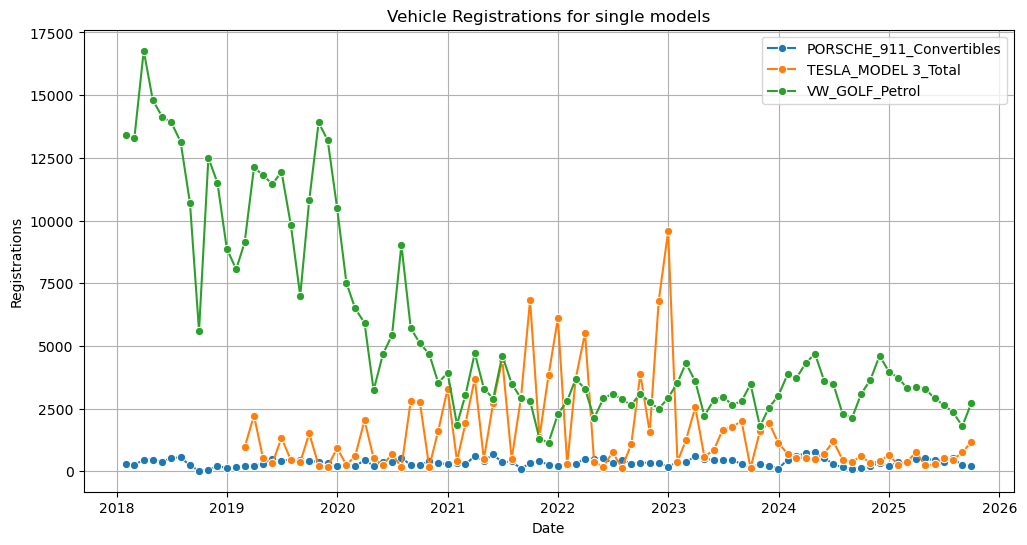

In [88]:
models = ['PORSCHE_911_Convertibles','TESLA_MODEL 3_Total','VW_GOLF_Petrol']
timeseries_key_list = models

time_col = 'Date'

plt.figure(figsize=(12, 6))

for ts_key in timeseries_key_list:
    df_subset = df[df['ts_key'] == ts_key].copy()
    if not df_subset.empty:
        df_subset = df_subset.sort_values(by=time_col)
        sns.lineplot(data=df_subset, x=time_col, y='Value', marker='o', label=ts_key)
    else:
        print(f"No data found for {ts_key}")

plt.title(f'Vehicle Registrations for single models')
plt.xlabel('Date')
plt.ylabel('Registrations')
plt.legend()
plt.grid(True)
plt.show()

The chart above displays registration volumes for three representative models throughout the observation period from January 2018 to September 2025. As demonstrated in the previous diagrams, individual model registration trajectories exhibit substantially greater volatility and noise compared to aggregated registration volumes across all models or within specific vehicle types.

The Tesla Model 3 registration pattern exemplifies this extreme volatility. Between December 2022 and January 2023, monthly registrations for this model fluctuated from more than 9,000 units to fewer than 500 units—a variation exceeding 1,700% within a single month. Similar fluctuations appear in high-volume models such as the VW Golf, though this series at least exhibits a discernible negative trend over the observation period.

The seasonal pattern observed in the convertible segment is also reflected in the individual time series of the Porsche 911, although the seasonality is less pronounced at this granular level compared to the aggregated category view.

### Autocorrelation

Autocorrelation shows how strongly current values of a time series depend on past values.
It helps identify whether the data contain meaningful temporal structure or are dominated by random noise.
Understanding autocorrelation is essential for selecting appropriate models and input sequence lengths, especially for neural networks.
High autocorrelation indicates that past observations carry predictive information about future values.
Without analyzing autocorrelation, models may be poorly specified and fail to capture important temporal dependencies.

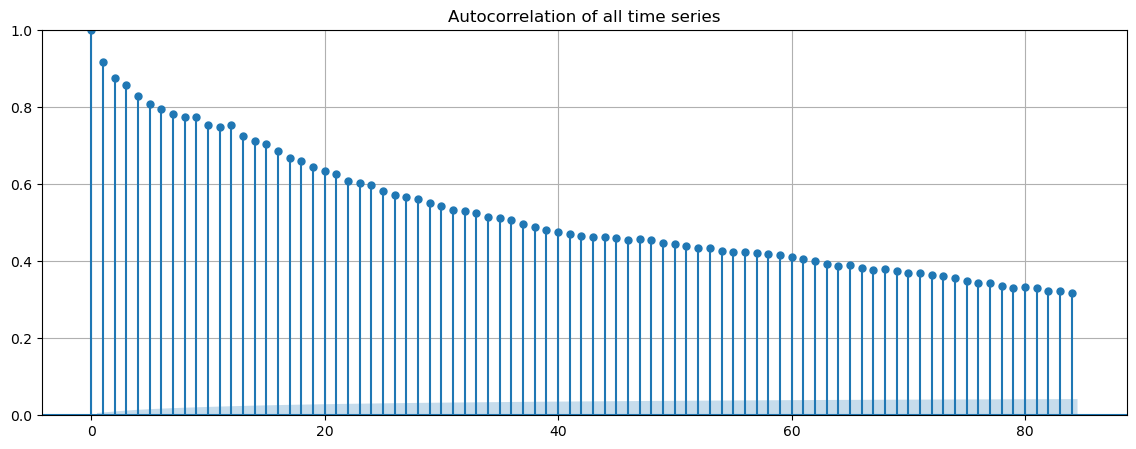

In [89]:
fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(df["Value"], lags=84, ax=ax)

ax.set_title("Autocorrelation of all time series")
ax.set_ylim(0, 1)
plt.grid(True)
plt.show()



The autocorrelation function of all time series shows a strong and slowly decaying positive autocorrelation across many lags, indicating a highly persistent and non-stationary time series. The autocorrelation values remain above 0.6 even at lag 84 (7 years), demonstrating that registration patterns exhibit long-term dependencies that persist well beyond seasonal cycles. The majority of autocorrelation values lie well outside the confidence interval (shaded region), confirming that the temporal dependencies are statistically significant and not driven by random noise.

#### Autocorrelation Analysis by Vehicle Type

In addition to the average autocorrelation across all time series, category-specific autocorrelation analyses were conducted to account for structural heterogeneity between different powertrain types.

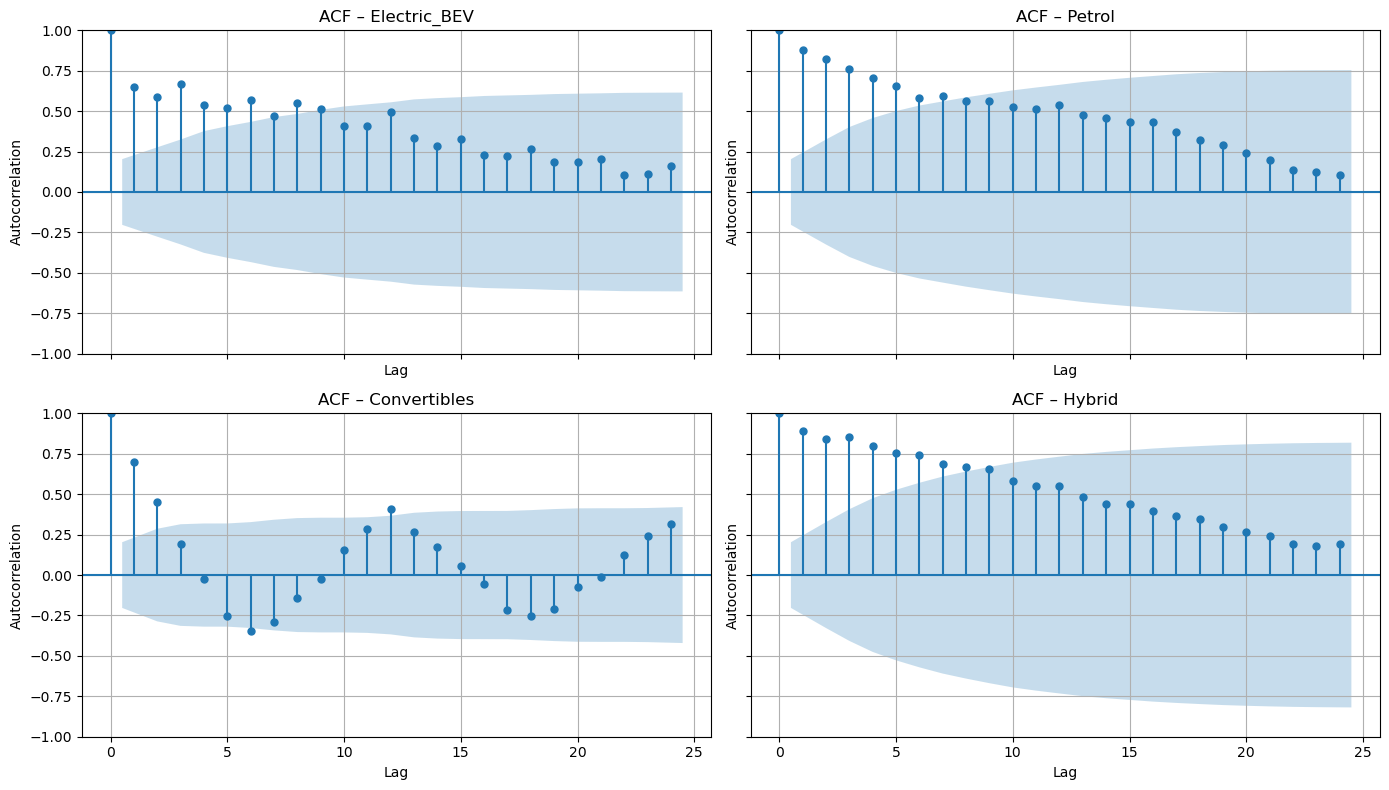

In [90]:
types = ["Electric_BEV", "Petrol", "Convertibles", "Hybrid"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, t in zip(axes, types):
    df_type = df[df["drive_type"] == t].copy()
    df_type = df_type.sort_values("Date")

    series = df_type.groupby("Date")["Value"].mean()
    series = series.dropna()

    plot_acf(series, lags=24, ax=ax)
    ax.set_title(f"ACF – {t}")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.set_ylim(-1, 1)
    ax.grid(True)
plt.tight_layout()
plt.show()

The autocorrelation function (ACF) plots above display the temporal dependencies within aggregated time series for four major vehicle drive types: Electric_BEV, Petrol, Convertibles, and Hybrid.



The autocorrelation of all BEV registrations shows rapid decay with values dropping sharply within the first few lags, indicating that past observations have limited predictive power for future electric vehicle registrations. This aligns with the earlier observation of high volatility and irregular patterns driven by policy interventions.

The petrol chart exhibits moderate autocorrelation that decays gradually, with significant correlations persisting beyond lag 12. This suggests more stable, predictable temporal patterns compared to electric vehicles, reflecting the established nature of the petrol vehicle segment.

Convertibles demonstrate strong autocorrelation with a clear seasonal pattern visible in the ACF (peaks at regular intervals), consistent with the strong 12-month seasonality observed in the time trend analysis.

Registrations of hybrid cars show autocorrelation patterns intermediate between petrol and electric vehicles, with gradual decay and some indication of seasonal components.

The varying autocorrelation structures across vehicle types underscore the heterogeneity in temporal dynamics.

#### Autocorrelation Analysis by OEM

Following the vehicle type analysis, autocorrelation patterns are examined at the manufacturer level to capture brand-specific temporal dynamics. This granular analysis reveals how different manufacturers exhibit distinct registration patterns influenced by their market positioning, product portfolios, and production strategies.

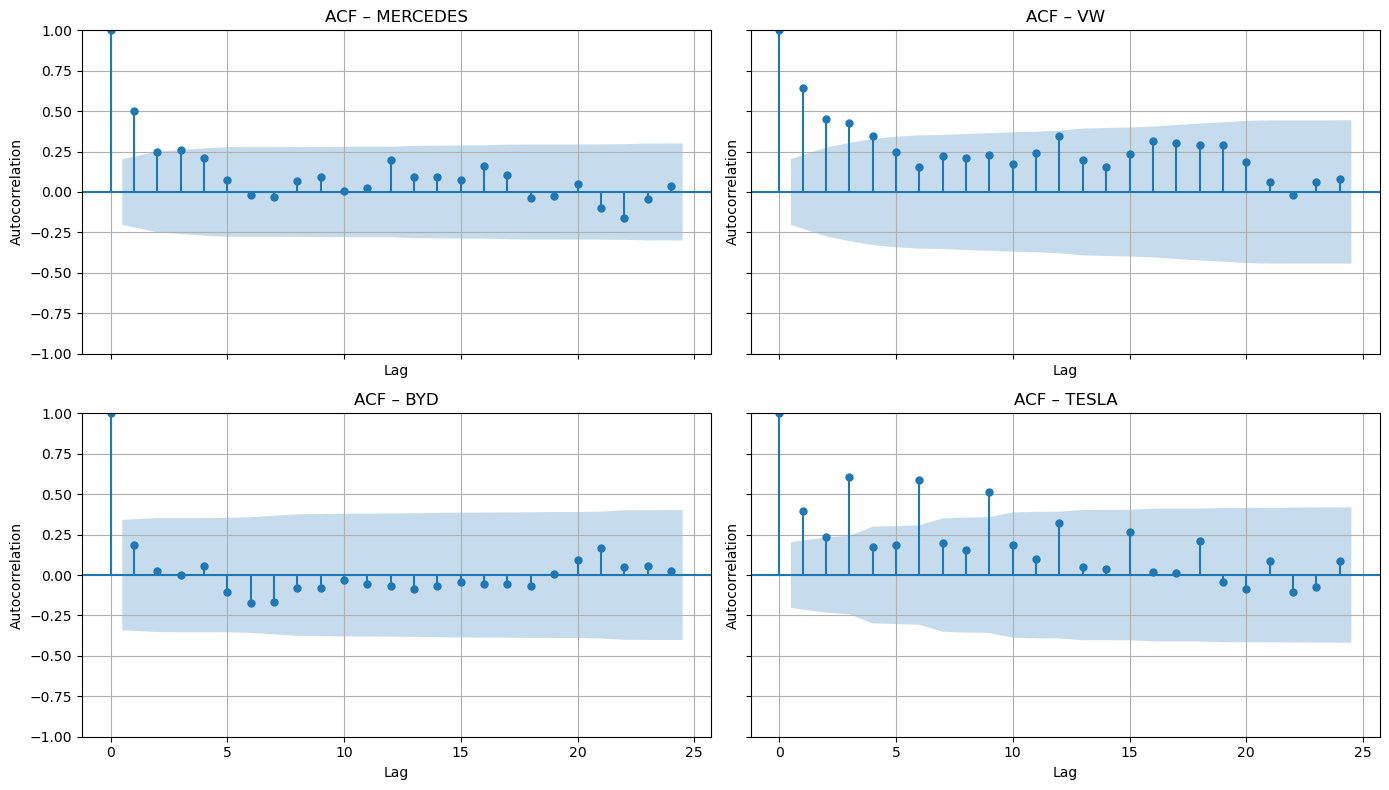

In [91]:
oems = ["MERCEDES", "VW", "BYD", "TESLA"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, oem in zip(axes, oems):
    df_oem = df[df["OEM"] == oem].copy()
    df_oem = df_oem.sort_values("Date")
    series = df_oem.groupby("Date")["Value"].mean()
    series = series.dropna()

    plot_acf(series, lags=24, ax=ax)
    ax.set_title(f"ACF – {oem}")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.set_ylim(-1, 1)
    ax.grid(True)

plt.tight_layout()
plt.show()


The four autocorrelation plots above display temporal dependencies for aggregated vehicle registrations across different manufacturers (OEMs). Compared to the aggregation by vehicle type shown earlier, all four OEM-level plots exhibit weaker temporal dependencies between consecutive months.

VW and Mercedes demonstrate at least short-term temporal dependencies, with autocorrelation coefficients at lag 1 exceeding 0.5, suggesting moderate predictability in the near term. In contrast, BYD exhibits particularly low serial dependence below the confidence intervall across nearly all lags, confirming the previously observed high volatility and less predictable registration patterns characteristic of electric vehicle manufacturers.

Tesla displays highly irregular autocorrelation patterns, with strong positive significant peaks at lags 3, 6, and 9, suggesting possible exogenous influences occurring at quarterly intervals—potentially related to production cycles or policy-driven delivery spikes. However, no clear systematic temporal dependency emerges from these patterns, making Tesla registrations particularly challenging to forecast using historical values alone.

These manufacturer-specific autocorrelation structures highlight substantial heterogeneity in temporal dynamics across OEMs, with traditional manufacturers showing more predictable patterns than electric-focused brands.

#### Autocorrelation Analysis by Vehicle Model

The final level of autocorrelation analysis examines individual vehicle models to assess temporal dependencies at the most granular level. This analysis reveals whether individual time series contain sufficient autocorrelation structure to support model-level forecasting or whether forecasting requires aggregation to higher levels.

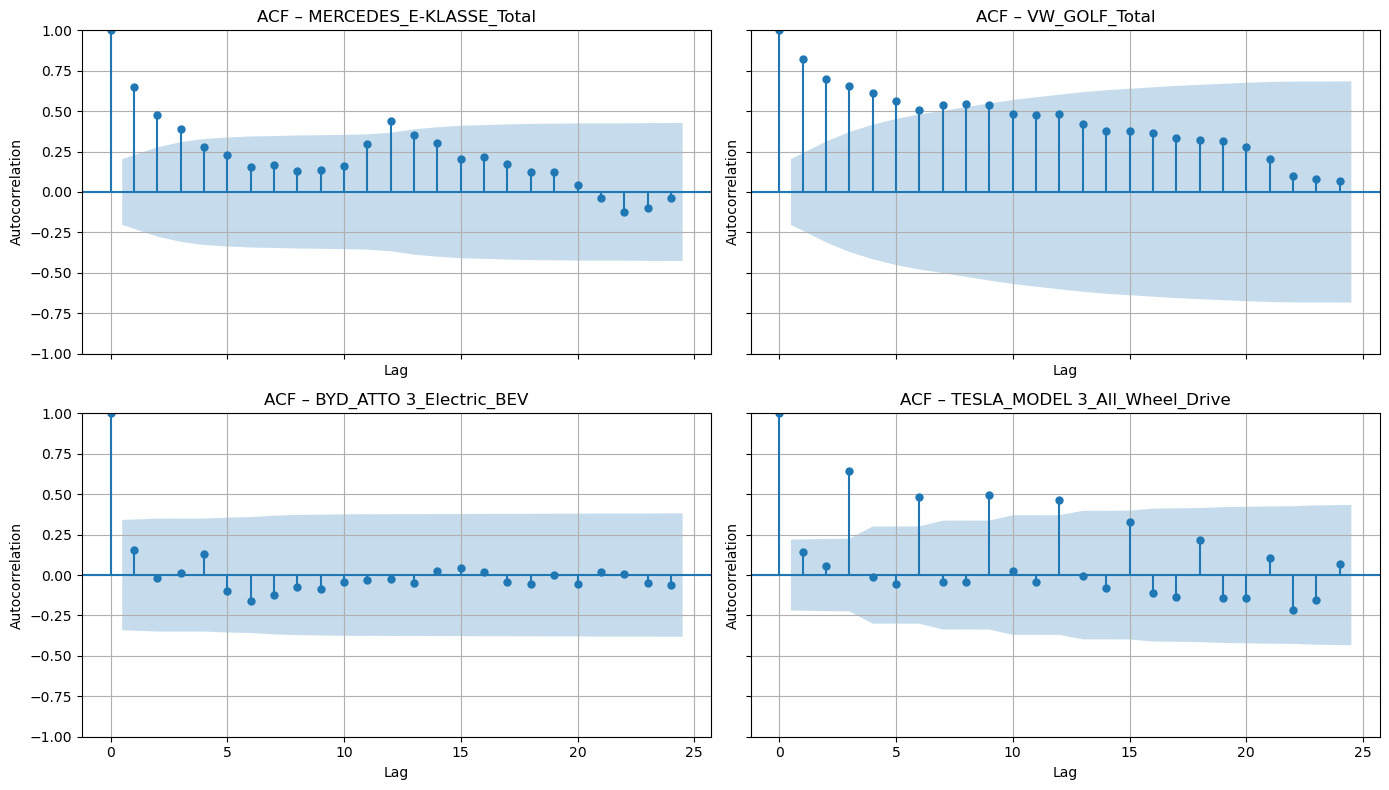

In [98]:
ts_keys = [
    "MERCEDES_E-KLASSE_Total",
    "VW_GOLF_Total",
    "BYD_ATTO 3_Electric_BEV",
    "TESLA_MODEL 3_All_Wheel_Drive"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, key in zip(axes, ts_keys):
    df_ts = df[df["ts_key"] == key].copy()
    df_ts = df_ts.sort_values("Date")

    series = df_ts["Value"].dropna()

    plot_acf(series, lags=24, ax=ax)
    ax.set_title(f"ACF – {key}")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelation")
    ax.set_ylim(-1, 1)
    ax.grid(True)

plt.tight_layout()
plt.show()


The autocorrelation plots above display temporal dependencies for four individual time series, representing specific vehicle models from the manufacturers analyzed earlier. The phenomena observed at the aggregated manufacturer level become even more pronounced when examining individual model series.

The VW Golf exhibits the strongest temporal dependency among the four models, with significant autocorrelation coefficients exceeding 0.5 through lag 6. This indicates long-term persistence without pronounced seasonality, suggesting relatively predictable registration patterns that make this model well-suited for time series forecasting.

In stark contrast, the BYD Atto 3 shows no significant autocorrelation structure even at lag 1, with all correlation coefficients falling within the confidence interval. This absence of serial dependence confirms the extreme difficulty of forecasting individual electric vehicle models, where historical values provide virtually no predictive information about future registrations.

The Tesla Model 3 exhibits the quarterly seasonal pattern previously observed in the manufacturer-level aggregation, with strong positive correlations at lags 3, 6, 9, and 12, while intervening months show no detectable temporal relationship. This three-month cycle likely reflects Tesla's production and delivery strategy combined with subsidy claim timing, creating a repeating spike pattern that differs fundamentally from traditional seasonal demand.

These individual model autocorrelation structures demonstrate that forecasting difficulty varies dramatically across vehicle segments, with traditional high-volume models offering the most predictable patterns and electric vehicles presenting significant challenges due to policy-driven volatility.

### Time dependent multivariate correlation

While the previous autocorrelation analysis examined temporal dependencies within individual time series, this section investigates cross-correlation patterns between exogenous variables and vehicle registration volumes. Unlike the contemporaneous correlation analysis presented earlier, which ignored the temporal dimension, cross-correlation analysis explicitly accounts for time lags to identify whether exogenous variables exhibit leading or lagging relationships with registration volumes. This analysis is crucial for understanding the temporal dynamics through which economic factors influence vehicle demand.

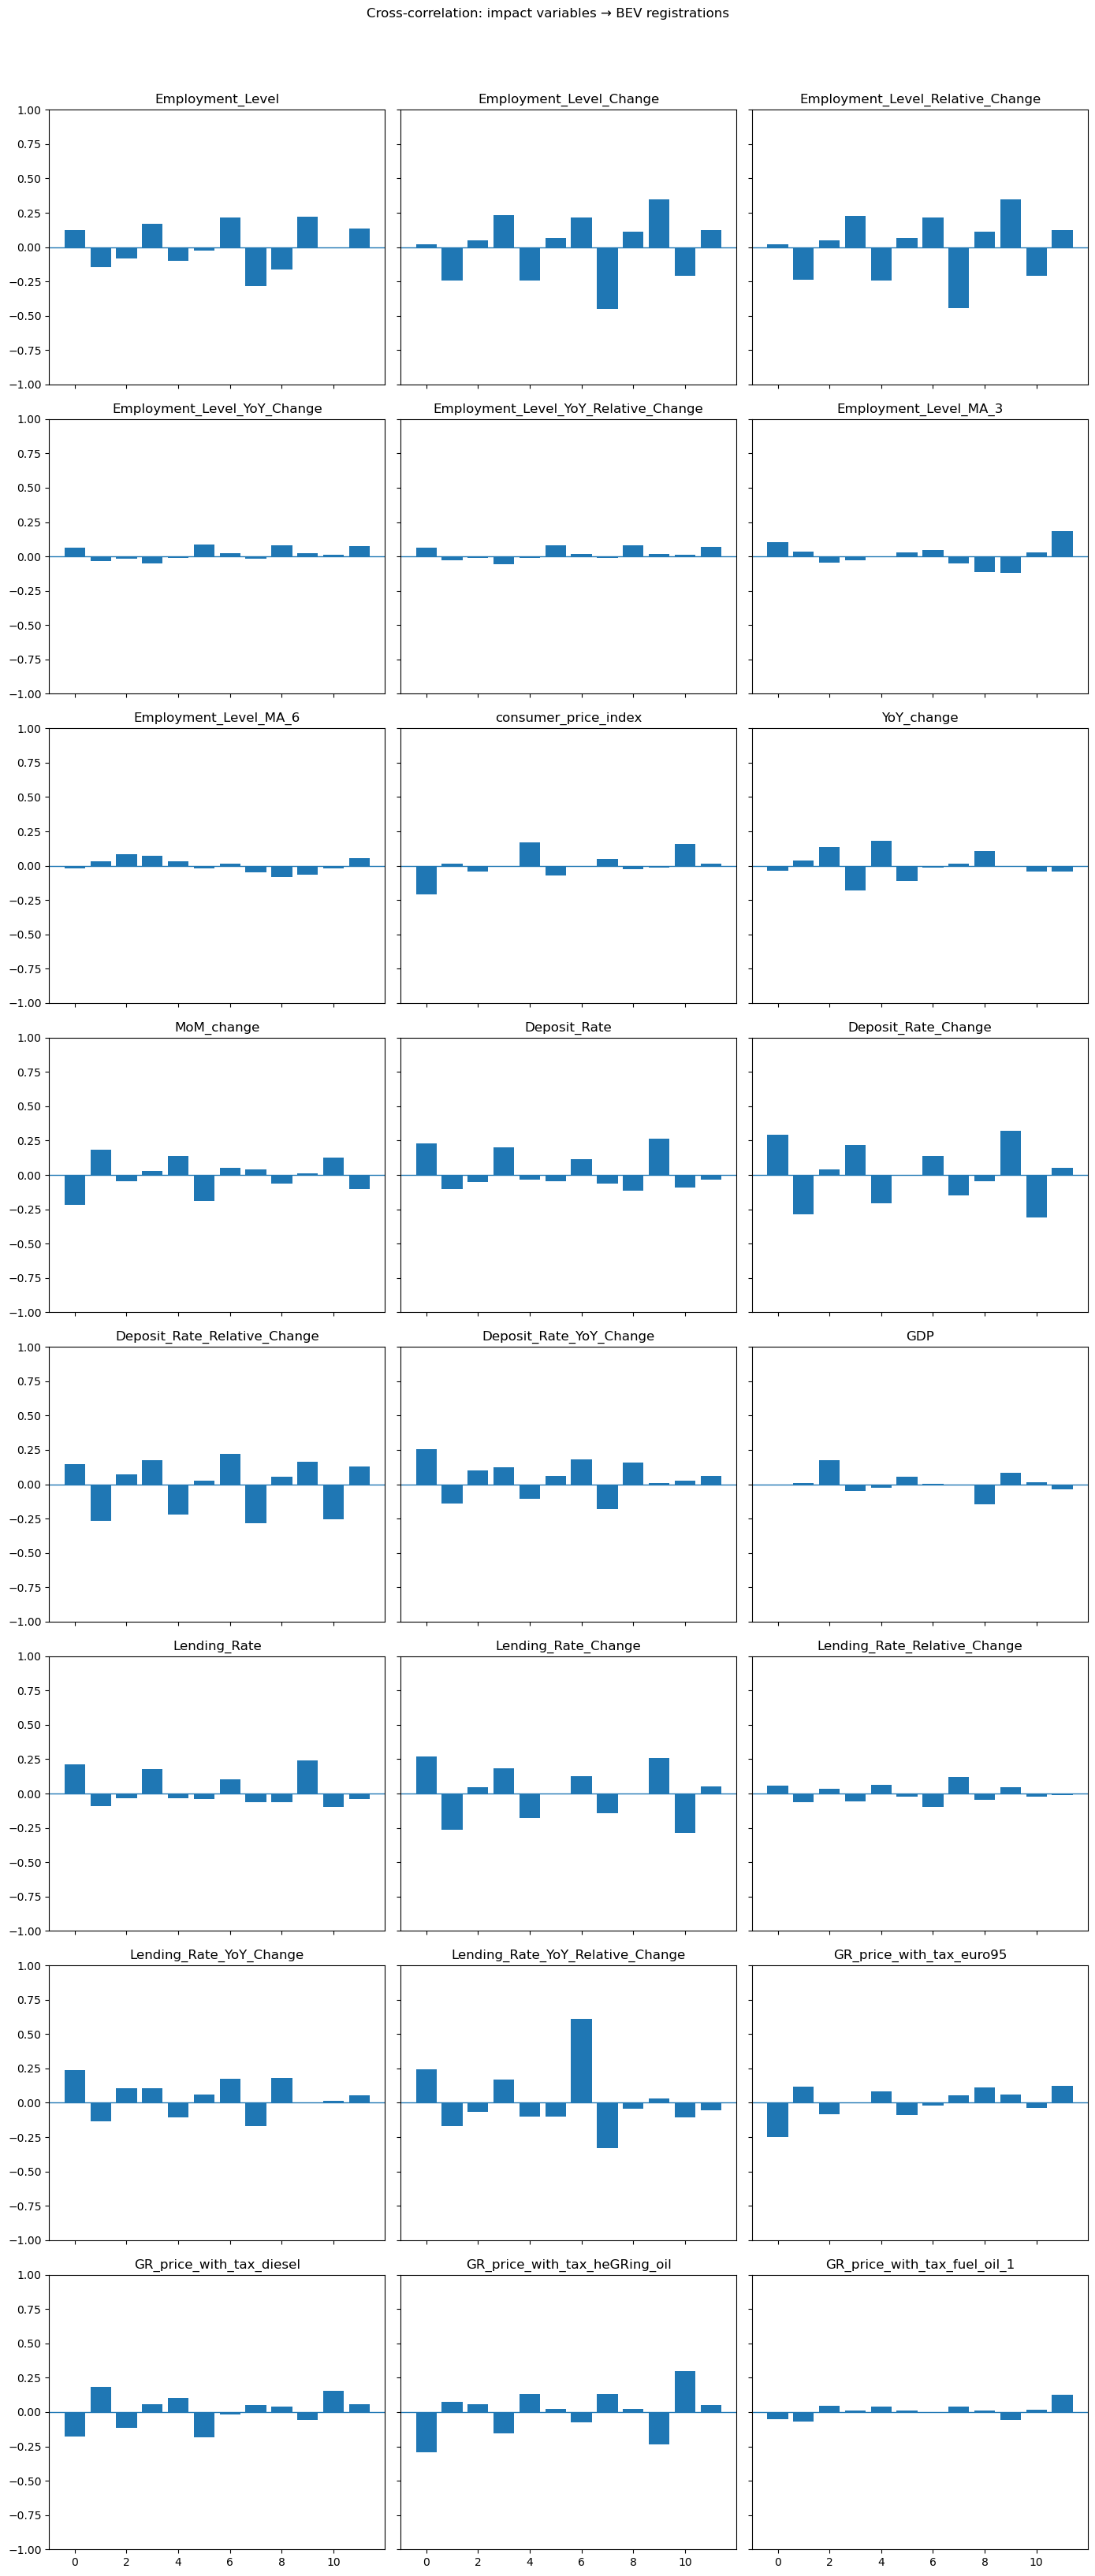

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Target series (choose type here)
target_type = "BEV"
target = df[df["type"] == target_type].groupby("Date")["Value"].mean()

# Impact columns (numeric only)
exclude = {"Date", "ts_key", "Value", "type", "oem"}
impact_cols = [c for c in df.select_dtypes("number").columns if c not in exclude]

n_cols = 3
n_rows = math.ceil(len(impact_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=True, sharey=True)
axes = np.ravel(axes)

for ax, col in zip(axes, impact_cols):
    impact = df.groupby("Date")[col].mean()
    d = pd.concat([impact, target], axis=1).dropna().diff().dropna()
    d = (d - d.mean()) / d.std()

    lags = min(12, len(d) - 1)
    if lags < 2 or d.isna().any().any():
        ax.axis("off"); continue

    cc = ccf(d.iloc[:, 0], d.iloc[:, 1])[:lags]
    ax.bar(range(lags), cc)
    ax.axhline(0, linewidth=1)
    ax.set_title(col)
    ax.set_ylim(-1, 1)

for ax in axes[len(impact_cols):]:
    ax.remove()

fig.suptitle(f"Cross-correlation: impact variables → {target_type} registrations", y=1.02)
plt.tight_layout()
plt.show()

The time dependent cross-correlation analysis reveals no clear and stable relationships between the considered exogenous variables and the registration numbers of battery electric vehicles (BEVs). Although isolated moderate correlation values are observed, these are neither temporally consistent nor stable across multiple lag periods. 

This multivariate time dependent correlation was also applied to different OEMs and vehicle models with the same results. Overall, this suggests that the examined macroeconomic factors exert only a limited direct influence on the registration numbers during the analyzed period.